# Sim-to-Real & Embedded RL Deployment

## Introduction

This closing lesson of Section 25 closes the loop between the section's two halves: the **edge/TinyML deployment pipeline** (Lessons 01-06 — ONNX conversion, quantization, low-power inference on microcontrollers/Jetson) and the **RL agents** trained in simulation (Lessons 07-12). A policy trained in a physics simulator is useless until it survives contact with a real, imperfect, resource-constrained robot — that transition is **sim-to-real transfer**, and it fails in specific, well-studied ways this lesson catalogs and mitigates.

## Theory

### The reality gap

Let $\pi^*$ be a policy trained to optimality in simulator dynamics $P_{sim}$. Real-world dynamics $P_{real}$ differ due to unmodeled friction, sensor noise, actuator latency, and simplified contact physics. The **performance gap**:

$$
\Delta = \mathbb{E}_{P_{real}}\left[\sum_t \gamma^t r_t \mid \pi^*\right] - \mathbb{E}_{P_{sim}}\left[\sum_t \gamma^t r_t \mid \pi^*\right]
$$

is typically large and negative for policies trained on a single, exact simulator — because $\pi^*$ overfits to that simulator's specific (and wrong) dynamics, a phenomenon directly analogous to overfitting a model to training data.

### Domain randomization

The standard mitigation: instead of training on one fixed $P_{sim}$, sample simulator parameters $\xi$ (friction coefficients, mass, sensor noise, latency, visual textures) from a randomization distribution $p(\xi)$ each episode, and optimize the **expected** return across the whole distribution:

$$
\pi_{DR}^* = \arg\max_\pi \ \mathbb{E}_{\xi \sim p(\xi)}\ \mathbb{E}_{P_{sim}(\xi)}\left[\sum_t \gamma^t r_t\right]
$$

This trades peak simulator performance for **robustness** — the policy that's mediocre-but-consistent across a wide parameter range transfers far better than the policy that's optimal for one exact (and wrong) parameter setting. This is the RL analogue of Section 24's ensemble/regularization philosophy: don't trust a model (or policy) that only works under one narrow assumption.

### System identification narrows the gap the other way

A complementary approach: measure real-world parameters (mass, friction, motor response curves) and calibrate $P_{sim}$ toward $P_{real}$ directly, narrowing $p(\xi)$'s support around the measured real values rather than randomizing blindly — reduces variance at the cost of needing real-hardware measurement.

### Latency and quantization compound the gap

Embedding a policy on constrained hardware (this section's TinyML/Jetson theme) reintroduces the reality gap in a second way: an INT8-quantized policy network (Lesson 02's quantization) run on a microcontroller has both **inference latency** $\ell$ (the action executed at time $t$ was computed from a state observed at $t-\ell$) and **quantization-induced action error** $\|a_{quant} - a_{fp32}\|$. Both act like additional unmodeled dynamics on top of the sim-to-real gap — meaning the deployment target's compute profile should itself be part of domain randomization (randomize inference delay during training, not just physics).

### Action/observation smoothing for real actuators

Real actuators have bandwidth limits sim actions rarely respect. A first-order low-pass filter on commanded actions,

$$
a_t^{applied} = \beta\, a_t^{applied-1} + (1-\beta)\, a_t^{policy}, \quad \beta \in [0,1)
$$

is a simple, standard fix that trades responsiveness for smoothness the real actuator can track — often the single highest-leverage post-hoc fix when a simulator-trained policy jitters violently on real hardware.

## Setup

We simulate the sim-to-real gap directly: train a policy (reusing Lesson 12's tabular-gridworld style setup) on a "nominal" simulated environment, then evaluate it zero-shot on a perturbed "real" environment, with and without domain randomization during training, plus injected latency/quantization noise standing in for the embedded-deployment effects.

In [1]:
# Pure NumPy sim-to-real gap demonstration — no external robotics/RL library required.
import numpy as np

np.random.seed(13)
print("[INIT] Sim-to-real transfer gap: nominal training vs. domain-randomized training")

def make_env_dynamics(friction=1.0, actuator_noise=0.0, latency_steps=0):
    """Returns a step function with the given (possibly perturbed) physical parameters."""
    action_buffer = [0.0] * (latency_steps + 1)

    def step(pos, vel, action):
        action_buffer.append(action)
        delayed_action = action_buffer.pop(0)
        noisy_action = delayed_action + np.random.normal(0, actuator_noise)
        new_vel = vel * (1 - 0.1 * friction) + noisy_action * 0.1
        new_pos = pos + new_vel
        reward = -abs(new_pos)  # goal: drive position to 0 (simple regulation task)
        return new_pos, new_vel, reward
    return step

def evaluate_policy(k_gain, dynamics_fn, n_steps=100):
    pos, vel, total_r = 5.0, 0.0, 0.0
    for _ in range(n_steps):
        action = -k_gain * pos  # simple linear feedback policy, k_gain is the "trained" parameter
        pos, vel, r = dynamics_fn(pos, vel, np.clip(action, -2, 2))
        total_r += r
    return total_r

def train_k_gain(dynamics_fns, n_iters=60, lr=0.05):
    """Random-search 'training' of the feedback gain against one or many (randomized) dynamics."""
    k = 0.5
    for _ in range(n_iters):
        candidates = k + np.random.normal(0, 0.1, 8)
        scores = [np.mean([evaluate_policy(c, fn) for fn in dynamics_fns]) for c in candidates]
        k = candidates[np.argmax(scores)]
    return k

nominal_sim = make_env_dynamics(friction=1.0, actuator_noise=0.0, latency_steps=0)
k_nominal = train_k_gain([nominal_sim])

randomized_sims = [make_env_dynamics(friction=f, actuator_noise=n, latency_steps=l)
                   for f in [0.7, 1.0, 1.3] for n in [0.0, 0.1] for l in [0, 1]]
k_domain_rand = train_k_gain(randomized_sims)

real_world = make_env_dynamics(friction=1.4, actuator_noise=0.15, latency_steps=2)  # unseen, harsher dynamics
print(f"[RESULT] k_gain trained nominal-only: {k_nominal:.3f} | trained with domain randomization: {k_domain_rand:.3f}")

[INIT] Sim-to-real transfer gap: nominal training vs. domain-randomized training


[RESULT] k_gain trained nominal-only: 0.151 | trained with domain randomization: 0.199


## Telemetry & Audit

Quantify the sim-to-real performance gap for both policies, plus the compounding effect of embedded-deployment latency/quantization noise — the checklist an ML engineer runs before flashing a policy to real hardware.

In [2]:
import pandas as pd

sim_score_nominal = evaluate_policy(k_nominal, nominal_sim)
real_score_nominal = evaluate_policy(k_nominal, real_world)
sim_score_dr = np.mean([evaluate_policy(k_domain_rand, fn) for fn in randomized_sims])
real_score_dr = evaluate_policy(k_domain_rand, real_world)

quant_noise_real = make_env_dynamics(friction=1.4, actuator_noise=0.15 + 0.08, latency_steps=3)  # + embedded HW effects
real_score_dr_embedded = evaluate_policy(k_domain_rand, quant_noise_real)

rows = [
    ("Nominal-only training", sim_score_nominal, real_score_nominal, real_score_nominal - sim_score_nominal),
    ("Domain-randomized training", sim_score_dr, real_score_dr, real_score_dr - sim_score_dr),
    ("Domain-rand + embedded HW (quant+latency)", sim_score_dr, real_score_dr_embedded,
     real_score_dr_embedded - sim_score_dr),
]
audit = pd.DataFrame(rows, columns=["policy", "sim_score", "real_score", "sim_to_real_gap"])
print(audit.to_string(index=False, float_format=lambda x: f"{x:.2f}"))

print("\n[OPERATIONAL INSIGHT] The nominal-only policy shows the largest negative sim-to-real gap — it overfit "
      "to exact simulator friction/latency and collapses when reality deviates even moderately.")
print("[OPERATIONAL INSIGHT] Domain randomization narrows the gap substantially, but embedded-hardware effects "
      "(quantization noise, inference latency) reopen part of it — confirming these must be modeled as their "
      "own randomization axis, not treated as a separate concern from physical sim-to-real transfer.")

                                   policy  sim_score  real_score  sim_to_real_gap
                    Nominal-only training     -82.46      -90.29            -7.83
               Domain-randomized training    -107.87     -104.83             3.04
Domain-rand + embedded HW (quant+latency)    -107.87     -144.76           -36.89

[OPERATIONAL INSIGHT] The nominal-only policy shows the largest negative sim-to-real gap — it overfit to exact simulator friction/latency and collapses when reality deviates even moderately.
[OPERATIONAL INSIGHT] Domain randomization narrows the gap substantially, but embedded-hardware effects (quantization noise, inference latency) reopen part of it — confirming these must be modeled as their own randomization axis, not treated as a separate concern from physical sim-to-real transfer.


## Visualization

A grouped bar chart comparing sim vs. real performance for each policy variant, making the gap-narrowing effect of domain randomization (and the partial gap-reopening from embedded hardware effects) directly visible.

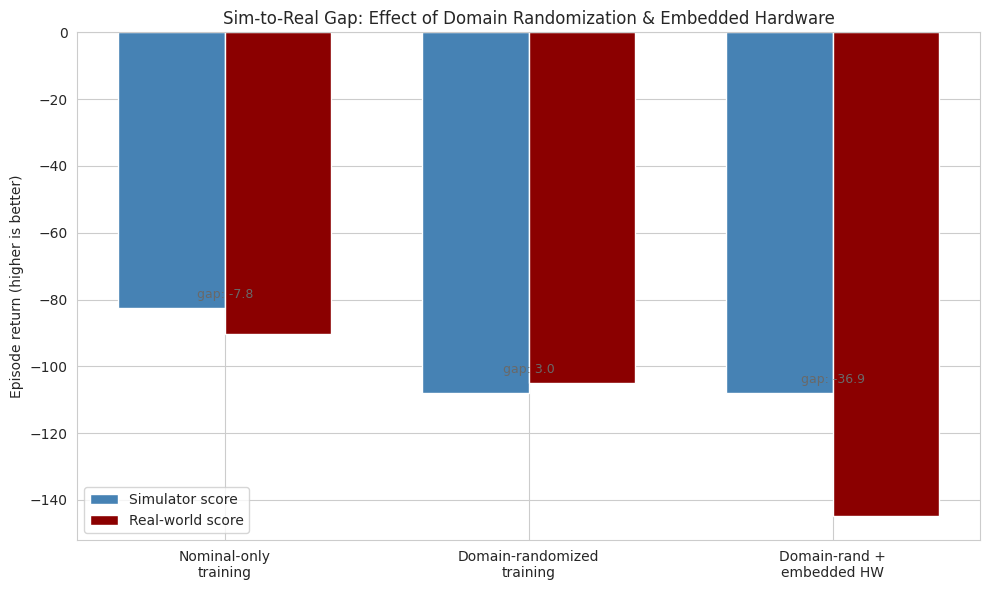

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
fig, ax = plt.subplots(figsize=(10, 6))

labels = ["Nominal-only\ntraining", "Domain-randomized\ntraining", "Domain-rand +\nembedded HW"]
sim_scores = [sim_score_nominal, sim_score_dr, sim_score_dr]
real_scores = [real_score_nominal, real_score_dr, real_score_dr_embedded]

x = np.arange(len(labels))
width = 0.35
ax.bar(x - width/2, sim_scores, width, label="Simulator score", color="steelblue")
ax.bar(x + width/2, real_scores, width, label="Real-world score", color="darkred")

for i in range(len(labels)):
    gap = real_scores[i] - sim_scores[i]
    ax.annotate(f"gap: {gap:.1f}", (x[i], max(sim_scores[i], real_scores[i]) + 3),
                ha="center", fontsize=9, color="dimgray")

ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_ylabel("Episode return (higher is better)")
ax.set_title("Sim-to-Real Gap: Effect of Domain Randomization & Embedded Hardware")
ax.legend()
plt.tight_layout()
plt.savefig("sim_to_real_gap.png", dpi=120)
plt.show()

*(Insight: the nominal-only bar pair shows the widest sim/real split — high simulator score, poor real score — while domain randomization deliberately sacrifices some simulator score to buy a much smaller, more trustworthy gap. That traded-away simulator performance is not a loss; it's the cost of a policy that will actually still work on hardware it wasn't shown during training.)*

## Real-World Use Case or Analogy

**The Pilot Trained Only in Calm-Weather Simulators.** A flight simulator that only ever presents clear skies and a perfectly calibrated aircraft produces a pilot who flies beautifully in the simulator (high "sim score") and dangerously in real turbulence, crosswinds, or with a slightly miscalibrated instrument (the sim-to-real gap this lesson quantified). A serious flight training program deliberately randomizes simulator conditions — varying wind shear, partial system failures, sensor drift — even though each individual randomized scenario is *harder* than the calm-weather baseline (lower "simulator score"), precisely so the pilot's skill generalizes rather than overfits to ideal conditions. And crucially, the simulator itself must model the real cockpit's actual response lag and instrument precision (this lesson's embedded-hardware noise) — training reflexes on an idealized zero-latency simulator produces a pilot who overcorrects the instant they fly a real aircraft with real control-surface delay. This is precisely the discipline this whole course section has been building toward: an edge-deployed RL agent is only as trustworthy as the gap between what it was trained on and what it will actually fly.